<a href="https://colab.research.google.com/github/simaryadav/learning_roadmap/blob/main/sp500.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Unsupervised Learning Trading Strategy
1.Download/Load SP500 stocks prices data.

2.Calculate different features and indicators on each stock.

3.Aggregate on monthly level and filter top 150 most liquid stocks.

4.Calculate Monthly Returns for different time-horizons.

5.Download Fama-French Factors and Calculate Rolling Factor Betas.

6.For each month fit a K-Means Clustering Algorithm to group similar assets based on their features.

7.For each month select assets based on the cluster and form a portfolio based on Efficient Frontier max sharpe ratio optimization.

8.Visualize Portfolio returns and compare to SP500 returns.

In [ ]:
!pip install data_reader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.0/149.0 kB 5.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import data_reader
import yfinance as yf
import pandas_datareader as pdr
from datetime import datetime
import warnings
import statsmodels.api as sm # Added this import
from statsmodels.regression.rolling import RollingOLS
warnings.filterwarnings('ignore')

In [ ]:
!pip install pandas_ta
!pip install PyPortfolioOpt
import pandas_ta
import pypfopt

In [ ]:
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
sp500 = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies', storage_options=headers)[0]

sp500['Symbol'] = sp500['Symbol'].str.replace('.', '-')

symbols_list = sp500['Symbol'].unique().tolist()

In [ ]:
sp500.head()
symbols_list

['MMM',
 'AOS',
 'ABT',
 'ABBV',
 'ACN',
 'ADBE',
 'AMD',
 'AES',
 'AFL',
 'A',
 'APD',
 'ABNB',
 'AKAM',
 'ALB',
 'ARE',
 'ALGN',
 'ALLE',
 'LNT',
 'ALL',
 'GOOGL',
 'GOOG',
 'MO',
 'AMZN',
 'AMCR',
 'AEE',
 'AEP',
 'AXP',
 'AIG',
 'AMT',
 'AWK',
 'AMP',
 'AME',
 'AMGN',
 'APH',
 'ADI',
 'AON',
 'APA',
 'APO',
 'AAPL',
 'AMAT',
 'APP',
 'APTV',
 'ACGL',
 'ADM',
 'ARES',
 'ANET',
 'AJG',
 'AIZ',
 'T',
 'ATO',
 'ADSK',
 'ADP',
 'AZO',
 'AVB',
 'AVY',
 'AXON',
 'BKR',
 'BALL',
 'BAC',
 'BAX',
 'BDX',
 'BRK-B',
 'BBY',
 'TECH',
 'BIIB',
 'BLK',
 'BX',
 'XYZ',
 'BK',
 'BA',
 'BKNG',
 'BSX',
 'BMY',
 'AVGO',
 'BR',
 'BRO',
 'BF-B',
 'BLDR',
 'BG',
 'BXP',
 'CHRW',
 'CDNS',
 'CPT',
 'CPB',
 'COF',
 'CAH',
 'CCL',
 'CARR',
 'CAT',
 'CBOE',
 'CBRE',
 'CDW',
 'COR',
 'CNC',
 'CNP',
 'CF',
 'CRL',
 'SCHW',
 'CHTR',
 'CVX',
 'CMG',
 'CB',
 'CHD',
 'CI',
 'CINF',
 'CTAS',
 'CSCO',
 'C',
 'CFG',
 'CLX',
 'CME',
 'CMS',
 'KO',
 'CTSH',
 'COIN',
 'CL',
 'CMCSA',
 'CAG',
 'COP',
 'ED',
 'STZ',
 'CEG',

In [ ]:
type(sp500)

pandas.core.frame.DataFrame

In [ ]:
sp500.shape

(501, 8)

In [ ]:
sp500.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Symbol                 501 non-null    object
 1   Security               501 non-null    object
 2   GICS Sector            501 non-null    object
 3   GICS Sub-Industry      501 non-null    object
 4   Headquarters Location  501 non-null    object
 5   Date added             501 non-null    object
 6   CIK                    501 non-null    int64 
 7   Founded                501 non-null    object
dtypes: int64(1), object(7)
memory usage: 31.4+ KB


In [ ]:
sp500.describe()

,CIK
count,5.010000e+02
mean,8.542788e+05
std,5.820125e+05
min,1.800000e+03
25%,1.060400e+05
50%,9.125950e+05
75%,1.285785e+06
max,2.064953e+06


In [ ]:
end_date = '2023-09-27'

start_date = pd.to_datetime(end_date)-pd.DateOffset(365*8)

df = yf.download(tickers=symbols_list,
                 start=start_date,
                 end=end_date).stack()

df.index.names = ['date', 'ticker']

df.columns = df.columns.str.lower()

df

[*********************100%***********************]  501 of 501 completed
ERROR:yfinance:
6 Failed downloads:
ERROR:yfinance:['Q', 'GEV', 'SNDK', 'VLTO', 'SOLS', 'SOLV']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-09-29 00:00:00 -> 2023-09-27) (Yahoo error = "Data doesn\'t exist for startDate = 1443499200, endDate = 1695787200")')


Price              adj close       close        high         low        open  \
date       ticker                                                              
2015-09-29 A             NaN   31.122833   31.418011   30.661618   30.772308   
           AAPL          NaN   24.484833   25.483894   24.215424   25.331229   
           ABBV          NaN   34.512188   35.427456   33.917263   34.714853   
           ABT           NaN   32.529423   33.064718   32.142363   32.331774   
           ACGL          NaN   23.217773   23.255808   22.916655   22.983217   
...                      ...         ...         ...         ...         ...   
2023-09-26 XYZ           NaN   44.810001   45.740002   44.560001   44.939999   
           YUM           NaN  118.719490  119.418343  118.183376  118.939674   
           ZBH           NaN  110.243698  114.802060  110.204486  114.468757   
           ZBRA          NaN  223.960007  226.649994  222.580002  225.970001   
           ZTS           NaN  172.425766  173.966067  171.840851  172.143059   

Price                   volume  
date       ticker               
2015-09-29 A         2252400.0  
           AAPL    293461600.0  
           ABBV     12842800.0  
           ABT      12287500.0  
           ACGL      1888800.0  
...                        ...  
2023-09-26 XYZ      10168200.0  
           YUM       1500600.0  
           ZBH       3610500.0  
           ZBRA       355400.0  
           ZTS       1463200.0  

[968223 rows x 6 columns]

In [ ]:
df.columns =  df.columns.str.lower()
df['adj close'] = df['close']
df

Price               adj close       close        high         low        open  \
date       ticker                                                               
2015-09-29 A        31.122833   31.122833   31.418011   30.661618   30.772308   
           AAPL     24.484833   24.484833   25.483894   24.215424   25.331229   
           ABBV     34.512188   34.512188   35.427456   33.917263   34.714853   
           ABT      32.529423   32.529423   33.064718   32.142363   32.331774   
           ACGL     23.217773   23.217773   23.255808   22.916655   22.983217   
...                       ...         ...         ...         ...         ...   
2023-09-26 XYZ      44.810001   44.810001   45.740002   44.560001   44.939999   
           YUM     118.719490  118.719490  119.418343  118.183376  118.939674   
           ZBH     110.243698  110.243698  114.802060  110.204486  114.468757   
           ZBRA    223.960007  223.960007  226.649994  222.580002  225.970001   
           ZTS     172.425766  172.425766  173.966067  171.840851  172.143059   

Price                   volume  
date       ticker               
2015-09-29 A         2252400.0  
           AAPL    293461600.0  
           ABBV     12842800.0  
           ABT      12287500.0  
           ACGL      1888800.0  
...                        ...  
2023-09-26 XYZ      10168200.0  
           YUM       1500600.0  
           ZBH       3610500.0  
           ZBRA       355400.0  
           ZTS       1463200.0  

[968223 rows x 6 columns]

2. Calculate features and technical indicators for each stock.

. Garman-Klass Volatility

. RSI

. Bollinger Bands

. ATR

. MACD

. Dollar Volume
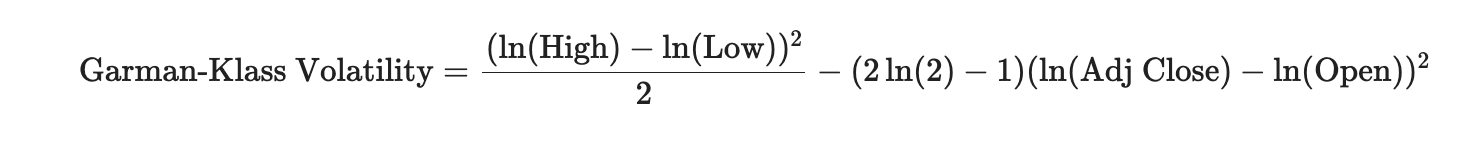

In [ ]:
df['garman_klass_vol'] = ((np.log(df['high'])-np.log(df['low']))**2)/2-(2*np.log(2)-1)*((np.log(df['adj close'])-np.log(df['open']))**2)

df['rsi'] = df.groupby(level=1)['adj close'].transform(lambda x: pandas_ta.rsi(close=x, length=20))

df['bb_low'] = df.groupby(level=1)['adj close'].transform(lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:,0])

df['bb_mid'] = df.groupby(level=1)['adj close'].transform(lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:,1])

df['bb_high'] = df.groupby(level=1)['adj close'].transform(lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:,2])

In [ ]:
def compute_atr(stock_data):
  atr = pandas_ta.atr(high=stock_data['high'], low=stock_data['low'], close=stock_data['close'], length=20)
  return atr.sub(atr.mean()).div(atr.std())

df['atr'] = df.groupby(level=1,group_keys=False).apply(compute_atr)

In [ ]:
def compute_macd(close):
    macd = pandas_ta.macd(close=close, length=20).iloc[:,0]
    return macd.sub(macd.mean()).div(macd.std())

df['macd'] = df.groupby(level=1, group_keys=False)['adj close'].apply(compute_macd)

df['dollar_volume'] = (df['adj close']*df['volume'])/1e6

df

Price               adj close       close        high         low        open  \
date       ticker                                                               
2015-09-29 A        31.122833   31.122833   31.418011   30.661618   30.772308   
           AAPL     24.484833   24.484833   25.483894   24.215424   25.331229   
           ABBV     34.512188   34.512188   35.427456   33.917263   34.714853   
           ABT      32.529423   32.529423   33.064718   32.142363   32.331774   
           ACGL     23.217773   23.217773   23.255808   22.916655   22.983217   
...                       ...         ...         ...         ...         ...   
2023-09-26 XYZ      44.810001   44.810001   45.740002   44.560001   44.939999   
           YUM     118.719490  118.719490  119.418343  118.183376  118.939674   
           ZBH     110.243698  110.243698  114.802060  110.204486  114.468757   
           ZBRA    223.960007  223.960007  226.649994  222.580002  225.970001   
           ZTS     172.425766  172.425766  173.966067  171.840851  172.143059   

Price                   volume  garman_klass_vol        rsi    bb_low  \
date       ticker                                                       
2015-09-29 A         2252400.0          0.000247        NaN       NaN   
           AAPL    293461600.0          0.000857        NaN       NaN   
           ABBV     12842800.0          0.000936        NaN       NaN   
           ABT      12287500.0          0.000386        NaN       NaN   
           ACGL      1888800.0          0.000068        NaN       NaN   
...                        ...               ...        ...       ...   
2023-09-26 XYZ      10168200.0          0.000338  25.939817  3.794872   
           YUM       1500600.0          0.000053  36.057187  4.782182   
           ZBH       3610500.0          0.000289  31.893238  4.733312   
           ZBRA       355400.0          0.000133  29.494977  5.397402   
           ZTS       1463200.0          0.000075  42.623496  5.136741   

Price                bb_mid   bb_high       atr      macd  dollar_volume  
date       ticker                                                         
2015-09-29 A            NaN       NaN       NaN       NaN      70.101070  
           AAPL         NaN       NaN       NaN       NaN    7185.358199  
           ABBV         NaN       NaN       NaN       NaN     443.233128  
           ABT          NaN       NaN       NaN       NaN     399.705282  
           ACGL         NaN       NaN       NaN       NaN      43.853730  
...                     ...       ...       ...       ...            ...  
2023-09-26 XYZ     3.980555  4.166238 -0.610991 -0.990293     455.637056  
           YUM     4.812919  4.843655  0.288017 -1.363695     178.150467  
           ZBH     4.774005  4.814698 -0.322299 -0.881067     398.034872  
           ZBRA    5.539167  5.680932  0.030109 -1.600791      79.595386  
           ZTS     5.197076  5.257411  0.759635 -1.188278     252.293381  

[968223 rows x 14 columns]

##3. Aggregate to monthly level and filter top 150 most liquid stocks for each month.

*   To reduce training time and experiment with features and strategies, we convert the business-daily data to month-end frequency.




In [ ]:
last_cols = [c for c in df.columns.unique(0) if c not in ['dollar_volume', 'volume', 'open',
                                                          'high', 'low', 'close']]

data = (pd.concat([df.unstack('ticker')['dollar_volume'].resample('M').mean().stack('ticker').to_frame('dollar_volume'),
                   df.unstack()[last_cols].resample('M').last().stack('ticker')],
                  axis=1)).dropna()

data

dollar_volume   adj close  garman_klass_vol        rsi  \
date       ticker                                                           
2015-11-30 A          134.434699   38.576061          0.000050  76.845836   
           AAPL      3996.837536   26.672970          0.000095  60.140368   
           ABBV       320.630197   38.367214          0.000362  57.773893   
           ABT        205.657579   37.207779          0.000043  64.476114   
           ACGL        28.174423   22.970539          0.000078  39.865158   
...                          ...         ...               ...        ...   
2023-09-30 APP        121.348834   38.590000          0.000732  51.250235   
           HOOD        63.043789    9.530000          0.000396  32.454969   
           CEG        194.905315  106.893997          0.000274  55.245467   
           GEHC       211.739362   65.962318          0.000185  40.914675   
           KVUE       632.390825   18.860455          0.000158  35.416235   

                     bb_low    bb_mid   bb_high       atr      macd  
date       ticker                                                    
2015-11-30 A       3.532920  3.607227  3.681535 -1.075468  0.567157  
           AAPL    3.274040  3.318466  3.362892 -0.969340 -0.142790  
           ABBV    3.675246  3.724687  3.774129 -0.693327  0.145676  
           ABT     3.627478  3.649882  3.672287 -1.069508  0.335557  
           ACGL    3.177527  3.195190  3.212853 -1.158113 -0.550166  
...                     ...       ...       ...       ...       ...  
2023-09-30 APP     3.651128  3.744206  3.837284 -0.740288  0.205403  
           HOOD    2.359019  2.444530  2.530040 -0.661059  0.204651  
           CEG     4.642175  4.683388  4.724601 -0.623615  0.366875  
           GEHC    4.151439  4.210467  4.269496 -0.982440 -1.116463  
           KVUE    2.956328  3.033011  3.109694 -1.094430 -1.435620  

[45716 rows x 9 columns]

In [ ]:
data

dollar_volume   adj close  garman_klass_vol        rsi  \
date       ticker                                                           
2015-11-30 A          134.434699   38.576061          0.000050  76.845836   
           AAPL      3996.837536   26.672970          0.000095  60.140368   
           ABBV       320.630197   38.367214          0.000362  57.773893   
           ABT        205.657579   37.207779          0.000043  64.476114   
           ACGL        28.174423   22.970539          0.000078  39.865158   
...                          ...         ...               ...        ...   
2023-09-30 APP        121.348834   38.590000          0.000732  51.250235   
           HOOD        63.043789    9.530000          0.000396  32.454969   
           CEG        194.905315  106.893997          0.000274  55.245467   
           GEHC       211.739362   65.962318          0.000185  40.914675   
           KVUE       632.390825   18.860455          0.000158  35.416235   

                     bb_low    bb_mid   bb_high       atr      macd  
date       ticker                                                    
2015-11-30 A       3.532920  3.607227  3.681535 -1.075468  0.567157  
           AAPL    3.274040  3.318466  3.362892 -0.969340 -0.142790  
           ABBV    3.675246  3.724687  3.774129 -0.693327  0.145676  
           ABT     3.627478  3.649882  3.672287 -1.069508  0.335557  
           ACGL    3.177527  3.195190  3.212853 -1.158113 -0.550166  
...                     ...       ...       ...       ...       ...  
2023-09-30 APP     3.651128  3.744206  3.837284 -0.740288  0.205403  
           HOOD    2.359019  2.444530  2.530040 -0.661059  0.204651  
           CEG     4.642175  4.683388  4.724601 -0.623615  0.366875  
           GEHC    4.151439  4.210467  4.269496 -0.982440 -1.116463  
           KVUE    2.956328  3.033011  3.109694 -1.094430 -1.435620  

[45716 rows x 9 columns]

Calculate 5-year rolling average of dollar volume for each stocks before filtering.

In [ ]:
data['dollar_volume'] = (data.loc[:, 'dollar_volume'].unstack('ticker').rolling(5*12, min_periods=12).mean().stack())

data['dollar_vol_rank'] = (data.groupby('date')['dollar_volume'].rank(ascending=False))

data = data[data['dollar_vol_rank']<150].drop(['dollar_volume', 'dollar_vol_rank'], axis=1)

data

adj close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2016-10-31 AAPL     26.035643          0.000041  49.891152  3.286970   
           ABBV     38.226246          0.000192  27.477856  3.701811   
           ABT      33.321083          0.000024  38.008984  3.525390   
           ACN     101.253761          0.000033  53.823772  4.614647   
           ADBE    107.510002          0.000059  53.668497  4.679120   
...                       ...               ...        ...       ...   
2023-09-30 DDOG     86.570000          0.000314  37.040091  4.474707   
           PLTR     13.960000          0.000214  41.544692  2.699917   
           DASH     74.580002          0.000326  36.955365  4.327250   
           ABNB    132.279999          0.000213  44.494127  4.854868   
           COIN     70.519997          0.001007  39.839731  4.270839   

                     bb_mid   bb_high       atr      macd  
date       ticker                                          
2016-10-31 AAPL    3.316593  3.346215 -1.048027 -0.195978  
           ABBV    3.757316  3.812820 -1.126936 -0.760594  
           ABT     3.577135  3.628879 -1.079265 -0.650889  
           ACN     4.626584  4.638522 -0.992380 -0.135457  
           ADBE    4.694639  4.710159 -1.256146 -0.109039  
...                     ...       ...       ...       ...  
2023-09-30 DDOG    4.560278  4.645848 -0.791145 -0.699392  
           PLTR    2.779743  2.859570 -0.370409 -0.433581  
           DASH    4.403906  4.480561 -1.165559 -0.117919  
           ABNB    4.940924  5.026980 -1.014340 -0.037854  
           COIN    4.378785  4.486731 -1.135285  0.049978  

[12516 rows x 8 columns]

##4. Calculate Monthly Returns for different time horizons as features.

* To capture time series dynamics that reflect, for example, momentum patterns,
 we compute historical returns using the method .pct_change(lag), that is, returns over various monthly periods as identified by lags.


In [ ]:
def calculate_returns(df):

    outlier_cutoff = 0.005

    lags = [1, 2, 3, 6, 9, 12]

    for lag in lags:

        df[f'return_{lag}m'] = (df['adj close']
                              .pct_change(lag)
                              .pipe(lambda x: x.clip(lower=x.quantile(outlier_cutoff),
                                                     upper=x.quantile(1-outlier_cutoff)))
                              .add(1)
                              .pow(1/lag)
                              .sub(1))
    return df


data = data.groupby(level=1, group_keys=False).apply(calculate_returns).dropna()

data

adj close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2017-10-31 AAPL     39.446003          0.000112  69.196832  3.586930   
           ABBV     64.105484          0.000173  55.247845  4.144826   
           ABT      47.118378          0.000036  53.844971  3.863786   
           ACN     126.506264          0.000019  69.365219  4.779217   
           ADBE    175.160004          0.000067  70.089317  4.948186   
...                       ...               ...        ...       ...   
2023-09-30 DDOG     86.570000          0.000314  37.040091  4.474707   
           PLTR     13.960000          0.000214  41.544692  2.699917   
           DASH     74.580002          0.000326  36.955365  4.327250   
           ABNB    132.279999          0.000213  44.494127  4.854868   
           COIN     70.519997          0.001007  39.839731  4.270839   

                     bb_mid   bb_high       atr      macd  return_1m  \
date       ticker                                                      
2017-10-31 AAPL    3.635012  3.683093 -0.927098 -0.039275   0.096808   
           ABBV    4.192355  4.239884 -0.151903  0.473814   0.022728   
           ABT     3.887954  3.912122 -1.079113  0.276133   0.021276   
           ACN     4.819920  4.860623 -0.998323  0.352342   0.064180   
           ADBE    5.089292  5.230398 -0.943340  0.612102   0.174152   
...                     ...       ...       ...       ...        ...   
2023-09-30 DDOG    4.560278  4.645848 -0.791145 -0.699392  -0.102716   
           PLTR    2.779743  2.859570 -0.370409 -0.433581  -0.068091   
           DASH    4.403906  4.480561 -1.165559 -0.117919  -0.113515   
           ABNB    4.940924  5.026980 -1.014340 -0.037854   0.005549   
           COIN    4.378785  4.486731 -1.135285  0.049978  -0.114070   

                   return_2m  return_3m  return_6m  return_9m  return_12m  
date       ticker                                                          
2017-10-31 AAPL     0.015250   0.044955   0.028875   0.038941    0.035229  
           ABBV     0.098590   0.091379   0.056495   0.047273    0.044026  
           ABT      0.034308   0.034801   0.038672   0.031320    0.029294  
           ACN      0.048454   0.037203   0.028692   0.027398    0.018728  
           ADBE     0.062497   0.061392   0.045993   0.049515    0.041515  
...                      ...        ...        ...        ...         ...  
2023-09-30 DDOG    -0.138786  -0.041732   0.029624   0.018352   -0.002098  
           PLTR    -0.161174  -0.030723   0.087272   0.090143    0.046083  
           DASH    -0.093658  -0.008091   0.027006   0.048207    0.034568  
           ABNB    -0.067704   0.010603   0.010289   0.049124    0.019401  
           COIN    -0.154340  -0.004822   0.007147   0.079010    0.007477  

[10335 rows x 14 columns]

##5. Download Fama-French Factors and Calculate Rolling Factor Betas.

* We will introduce the Fama—French data to estimate the exposure of assets to common risk factors using linear regression.

* The five Fama—French factors, namely market risk, size, value, operating profitability, and investment have been shown empirically to explain asset returns and are commonly used to assess the risk/return profile of portfolios. Hence, it is natural to include past factor exposures as financial features in models.

* We can access the historical factor returns using the pandas-datareader and estimate historical exposures using the RollingOLS rolling linear regression.



In [ ]:
import pandas_datareader.data as web
factor_data = web.DataReader('F-F_Research_Data_5_Factors_2x3',
                               'famafrench',
                               start='2010')[0].drop('RF', axis=1)

factor_data.index = factor_data.index.to_timestamp()

factor_data = factor_data.resample('M').last().div(100)

factor_data.index.name = 'date'

factor_data = factor_data.join(data['return_1m']).sort_index()

factor_data

Mkt-RF     SMB     HML     RMW     CMA  return_1m
date       ticker                                                   
2017-10-31 AAPL    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.096808
           ABBV    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.022728
           ABT     0.0225 -0.0191  0.0013  0.0092 -0.0314   0.021276
           ACN     0.0225 -0.0191  0.0013  0.0092 -0.0314   0.064180
           ADBE    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.174152
...                   ...     ...     ...     ...     ...        ...
2023-09-30 WDAY   -0.0523 -0.0178  0.0149  0.0187 -0.0077  -0.062413
           WFC    -0.0523 -0.0178  0.0149  0.0187 -0.0077  -0.015500
           WMT    -0.0523 -0.0178  0.0149  0.0187 -0.0077  -0.000677
           XOM    -0.0523 -0.0178  0.0149  0.0187 -0.0077   0.046947
           XYZ    -0.0523 -0.0178  0.0149  0.0187 -0.0077  -0.222723

[10335 rows x 6 columns]

Filter out stocks with less than 10 months of data.

In [ ]:
observations = factor_data.groupby(level=1).size()

valid_stocks = observations[observations >= 10]

factor_data = factor_data[factor_data.index.get_level_values('ticker').isin(valid_stocks.index)]

factor_data

Mkt-RF     SMB     HML     RMW     CMA  return_1m
date       ticker                                                   
2017-10-31 AAPL    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.096808
           ABBV    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.022728
           ABT     0.0225 -0.0191  0.0013  0.0092 -0.0314   0.021276
           ACN     0.0225 -0.0191  0.0013  0.0092 -0.0314   0.064180
           ADBE    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.174152
...                   ...     ...     ...     ...     ...        ...
2023-09-30 WDAY   -0.0523 -0.0178  0.0149  0.0187 -0.0077  -0.062413
           WFC    -0.0523 -0.0178  0.0149  0.0187 -0.0077  -0.015500
           WMT    -0.0523 -0.0178  0.0149  0.0187 -0.0077  -0.000677
           XOM    -0.0523 -0.0178  0.0149  0.0187 -0.0077   0.046947
           XYZ    -0.0523 -0.0178  0.0149  0.0187 -0.0077  -0.222723

[10325 rows x 6 columns]

Calculate Rolling Factor Betas.

In [ ]:
betas = (factor_data.groupby(level=1,
                            group_keys=False)
         .apply(lambda x: RollingOLS(endog=x['return_1m'],
                                     exog=sm.add_constant(x.drop('return_1m', axis=1)),
                                     window=min(24, x.shape[0]),
                                     min_nobs=len(x.columns)+1)
         .fit(params_only=True)
         .params
         .drop('const', axis=1)))

betas

Mkt-RF       SMB       HML       RMW       CMA
date       ticker                                                  
2017-10-31 AAPL         NaN       NaN       NaN       NaN       NaN
           ABBV         NaN       NaN       NaN       NaN       NaN
           ABT          NaN       NaN       NaN       NaN       NaN
           ACN          NaN       NaN       NaN       NaN       NaN
           ADBE         NaN       NaN       NaN       NaN       NaN
...                     ...       ...       ...       ...       ...
2023-09-30 WDAY    1.081294 -0.943555 -0.563449 -0.906461 -0.245237
           WFC     1.121906  0.242620  2.052791 -0.496743 -1.544787
           WMT     0.703929 -0.314848 -0.404456 -0.145652  0.500326
           XOM     0.983535 -1.132691  1.727329 -0.688780 -0.355284
           XYZ     2.418104  1.932541 -0.346938 -1.675264  0.483283

[10325 rows x 5 columns]

Join the rolling factors data to the main features dataframe.

In [ ]:
factors = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']

data = (data.join(betas.groupby('ticker').shift()))

data.loc[:, factors] = data.groupby('ticker', group_keys=False)[factors].apply(lambda x: x.fillna(x.mean()))

data = data.drop('adj close', axis=1)

data = data.dropna()

data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 10065 entries, (Timestamp('2017-10-31 00:00:00'), 'AAPL') to (Timestamp('2023-09-30 00:00:00'), 'DDOG')
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   garman_klass_vol  10065 non-null  float64
 1   rsi               10065 non-null  float64
 2   bb_low            10065 non-null  float64
 3   bb_mid            10065 non-null  float64
 4   bb_high           10065 non-null  float64
 5   atr               10065 non-null  float64
 6   macd              10065 non-null  float64
 7   return_1m         10065 non-null  float64
 8   return_2m         10065 non-null  float64
 9   return_3m         10065 non-null  float64
 10  return_6m         10065 non-null  float64
 11  return_9m         10065 non-null  float64
 12  return_12m        10065 non-null  float64
 13  Mkt-RF            10065 non-null  float64
 14  SMB               10065 non-null  float64
 15  HML      

###At this point we have to decide on what ML model and approach to use for predictions etc.
##6. For each month fit a K-Means Clustering Algorithm to group similar assets based on their features.
K-Means Clustering
You may want to initialize predefined centroids for each cluster based on your research.

* For visualization purpose of this tutorial we will initially rely on the ‘k-means++’ initialization.

* Then we will pre-define our centroids for each cluster.





In [ ]:
from sklearn.cluster import KMeans

# Drop 'cluster' column only if it exists
if 'cluster' in data.columns:
    data = data.drop('cluster', axis=1)

def get_clusters(df):
    df['cluster'] = KMeans(n_clusters=4,
                           random_state=0,
                           init="random").fit(df).labels_
    return df

data = data.dropna().groupby('date', group_keys=False).apply(get_clusters)

data

garman_klass_vol        rsi    bb_low    bb_mid   bb_high  \
date       ticker                                                              
2017-10-31 AAPL            0.000112  69.196832  3.586930  3.635012  3.683093   
           ABBV            0.000173  55.247845  4.144826  4.192355  4.239884   
           ABT             0.000036  53.844971  3.863786  3.887954  3.912122   
           ACN             0.000019  69.365219  4.779217  4.819920  4.860623   
           ADBE            0.000067  70.089317  4.948186  5.089292  5.230398   
...                             ...        ...       ...       ...       ...   
2023-09-30 XYZ             0.000338  25.939817  3.794872  3.980555  4.166238   
           MRNA            0.000146  38.747314  4.579843  4.685332  4.790820   
           UBER            0.000441  45.005268  3.805210  3.862227  3.919244   
           CRWD            0.000144  51.534803  5.024174  5.103696  5.183218   
           DDOG            0.000314  37.040091  4.474707  4.560278  4.645848   

                        atr      macd  return_1m  return_2m  return_3m  \
date       ticker                                                        
2017-10-31 AAPL   -0.927098 -0.039275   0.096808   0.015250   0.044955   
           ABBV   -0.151903  0.473814   0.022728   0.098590   0.091379   
           ABT    -1.079113  0.276133   0.021276   0.034308   0.034801   
           ACN    -0.998323  0.352342   0.064180   0.048454   0.037203   
           ADBE   -0.943340  0.612102   0.174152   0.062497   0.061392   
...                     ...       ...        ...        ...        ...   
2023-09-30 XYZ    -0.610991 -0.990293  -0.222723  -0.247423  -0.123607   
           MRNA   -0.534784 -0.376899  -0.132219  -0.086803  -0.068763   
           UBER   -0.802674 -0.133973  -0.062672  -0.053920   0.008422   
           CRWD   -0.734509  0.245950  -0.015641  -0.003656   0.029981   
           DDOG   -0.791145 -0.699392  -0.102716  -0.138786  -0.041732   

                   return_6m  return_9m  return_12m    Mkt-RF       SMB  \
date       ticker                                                         
2017-10-31 AAPL     0.028875   0.038941    0.035229  1.276515 -0.251055   
           ABBV     0.056495   0.047273    0.044026  0.505459  0.360798   
           ABT      0.038672   0.031320    0.029294  0.833391 -0.194861   
           ACN      0.028692   0.027398    0.018728  1.203789 -0.154565   
           ADBE     0.045993   0.049515    0.041515  1.109870 -0.318478   
...                      ...        ...         ...       ...       ...   
2023-09-30 XYZ     -0.068630  -0.036876   -0.016915  2.425978  1.934056   
           MRNA    -0.071952  -0.064976   -0.015431  1.153428  0.828198   
           UBER     0.057244   0.066838    0.043691  1.089758  1.125843   
           CRWD     0.026391   0.047942   -0.002216  0.596815 -0.979206   
           DDOG     0.029624   0.018352   -0.002098  0.597638  1.155577   

                        HML       RMW       CMA  cluster  
date       ticker                                         
2017-10-31 AAPL   -0.610537  0.680863  0.488799        1  
           ABBV   -0.030540  0.178920  0.188292        0  
           ABT    -0.528597  0.255574  0.985881        0  
           ACN    -0.339711  0.270240  0.196920        1  
           ADBE   -0.184535 -0.218372 -0.687463        1  
...                     ...       ...       ...      ...  
2023-09-30 XYZ    -0.380210 -1.635044  0.504781        3  
           MRNA   -1.184255  0.620191  1.032049        2  
           UBER   -0.231076 -1.533331 -0.491373        1  
           CRWD   -0.702721 -2.505550 -0.804831        0  
           DDOG   -0.671081 -0.676309 -0.694457        2  

[10065 rows x 19 columns]

In [ ]:
def plot_clusters(data):

    cluster_0 = data[data['cluster']==0]
    cluster_1 = data[data['cluster']==1]
    cluster_2 = data[data['cluster']==2]
    cluster_3 = data[data['cluster']==3]

    plt.scatter(cluster_0.iloc[:,0] , cluster_0.iloc[:,6] , color = 'red', label='cluster 0')
    plt.scatter(cluster_1.iloc[:,0] , cluster_1.iloc[:,6] , color = 'green', label='cluster 1')
    plt.scatter(cluster_2.iloc[:,0] , cluster_2.iloc[:,6] , color = 'blue', label='cluster 2')
    plt.scatter(cluster_3.iloc[:,0] , cluster_3.iloc[:,6] , color = 'black', label='cluster 3')

    plt.legend()
    plt.show()
    return

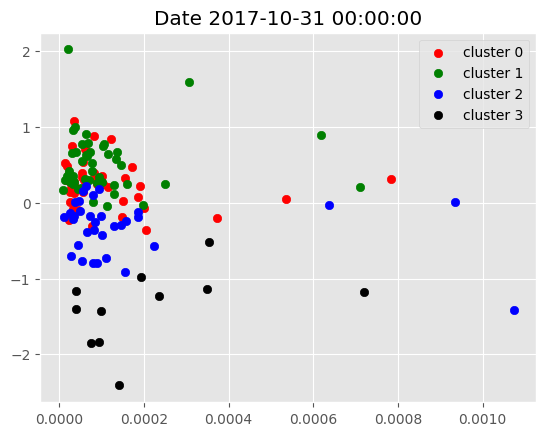

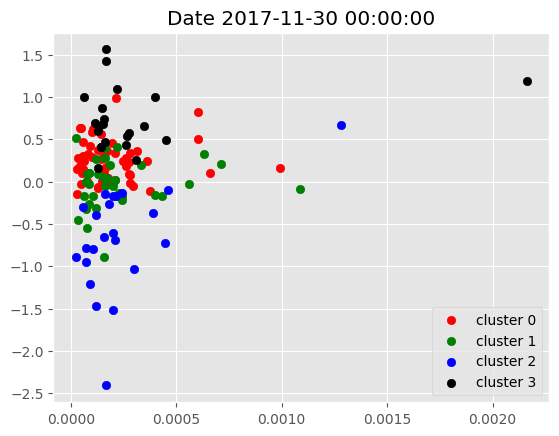

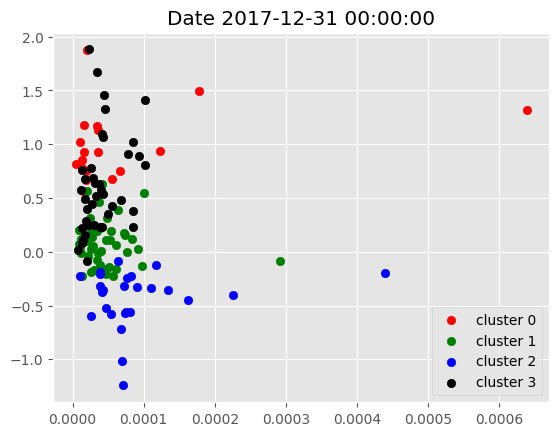

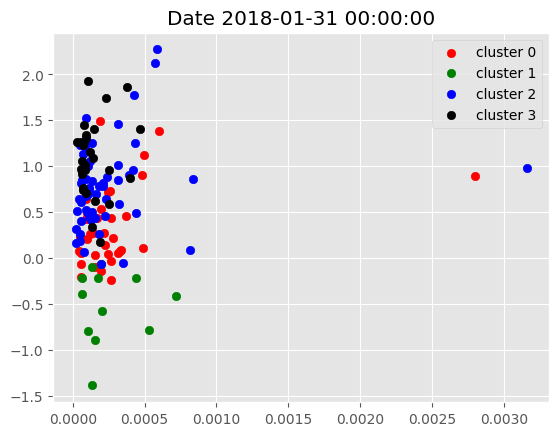

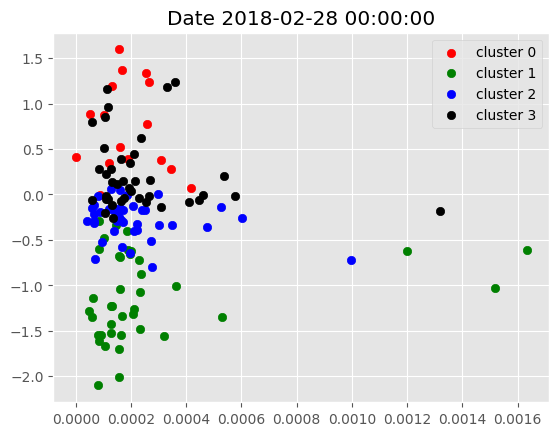

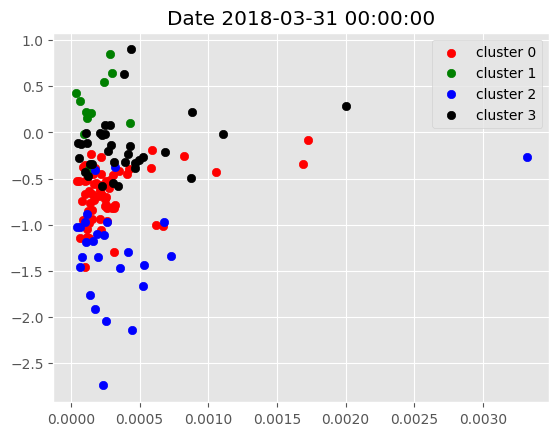

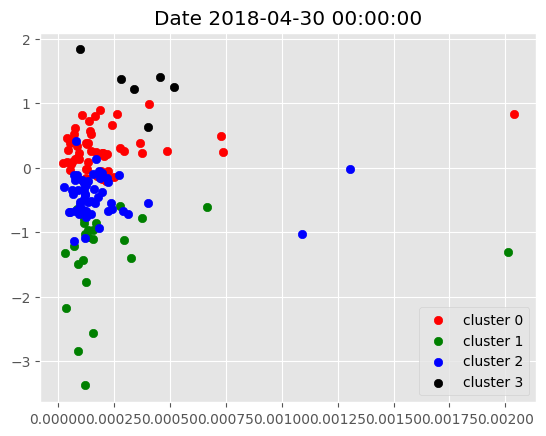

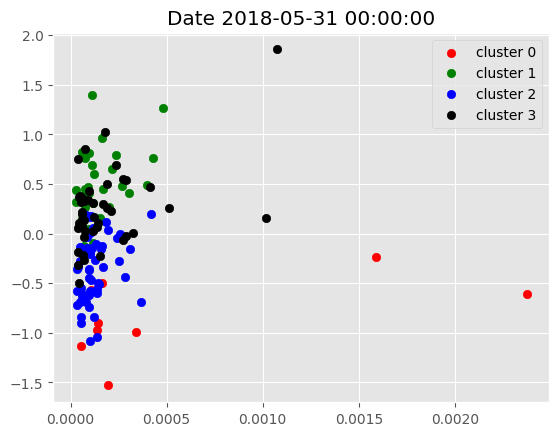

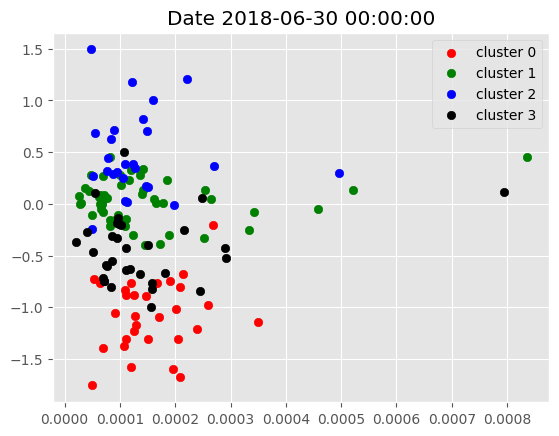

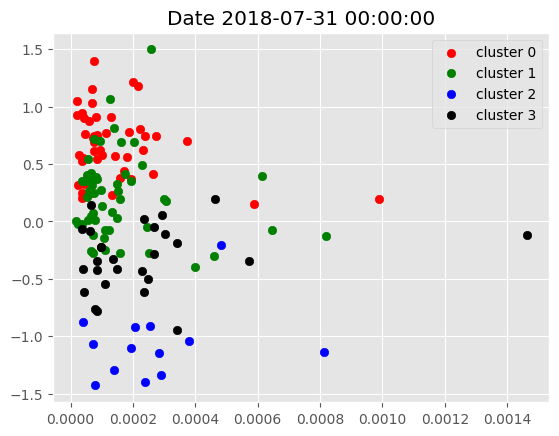

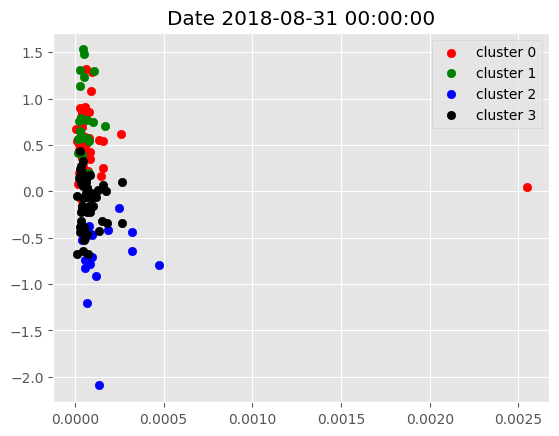

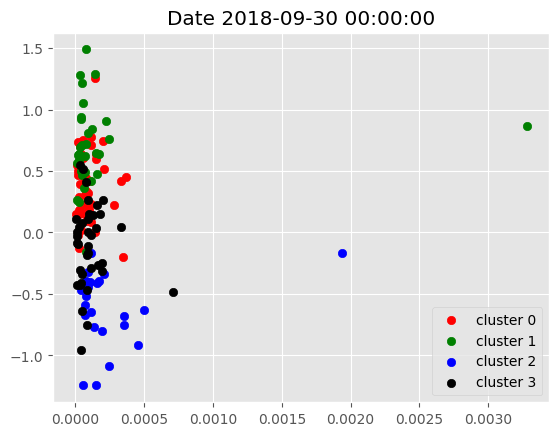

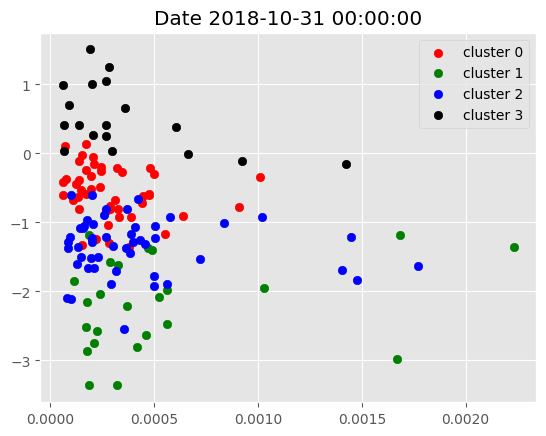

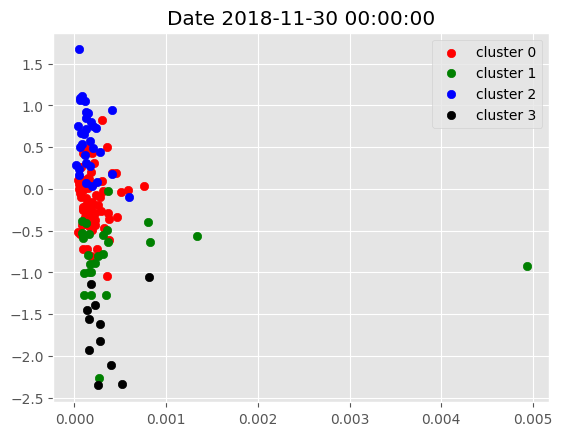

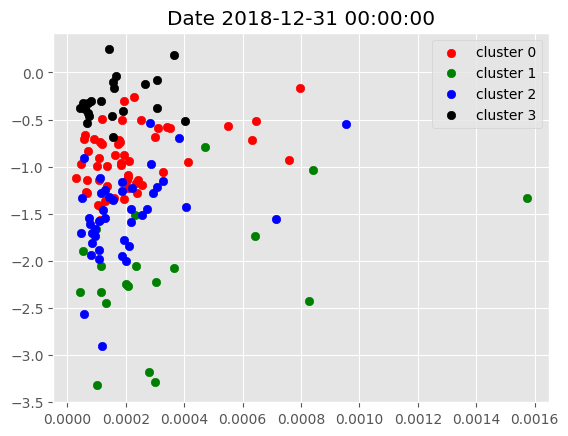

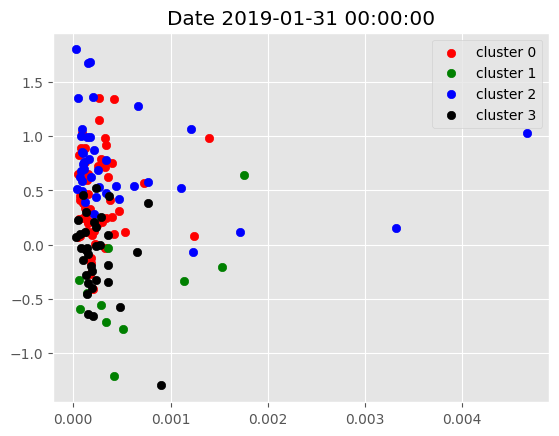

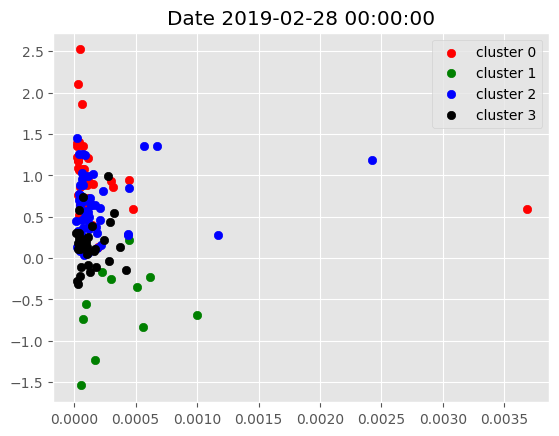

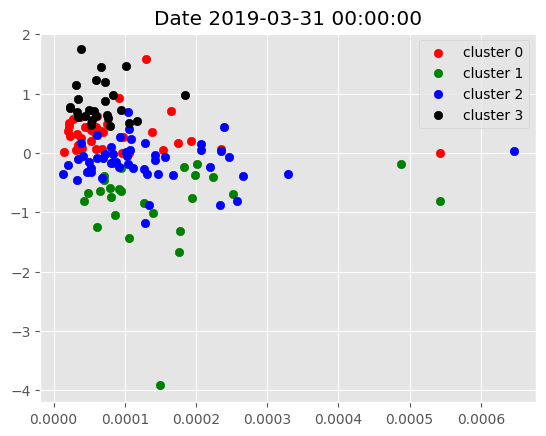

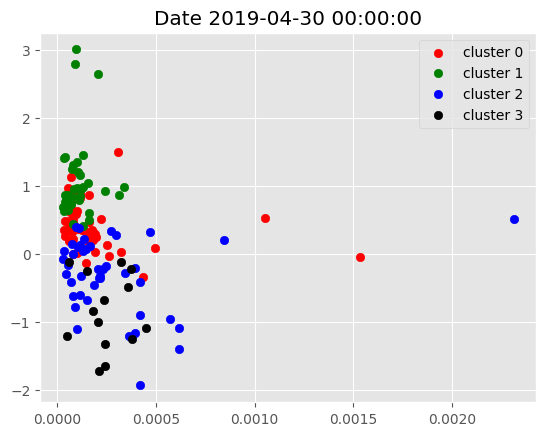

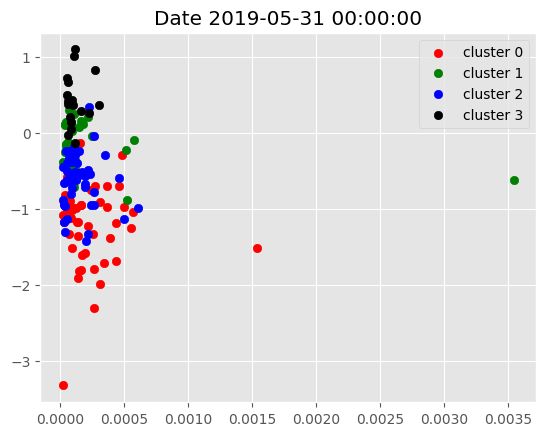

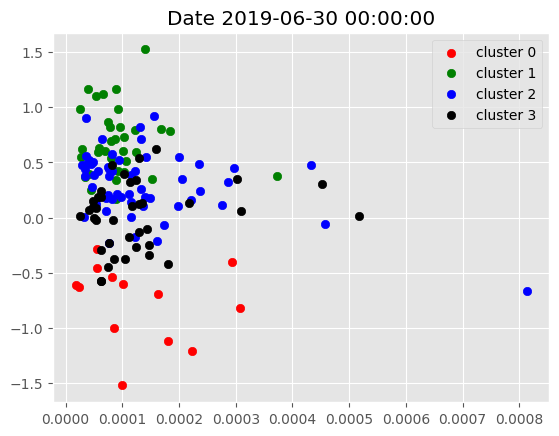

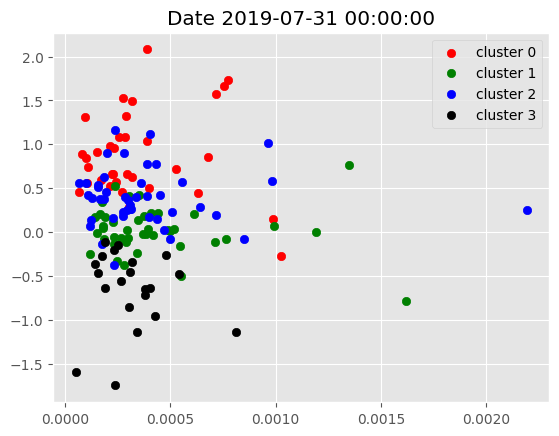

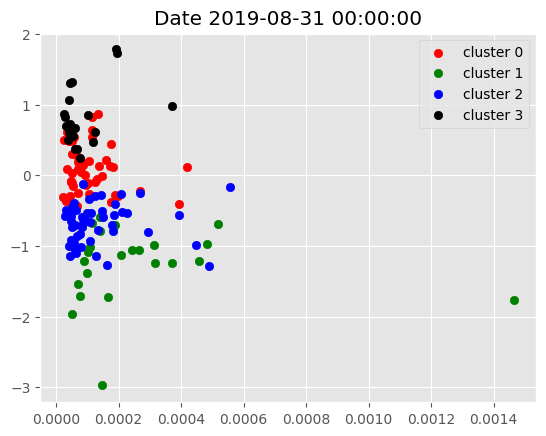

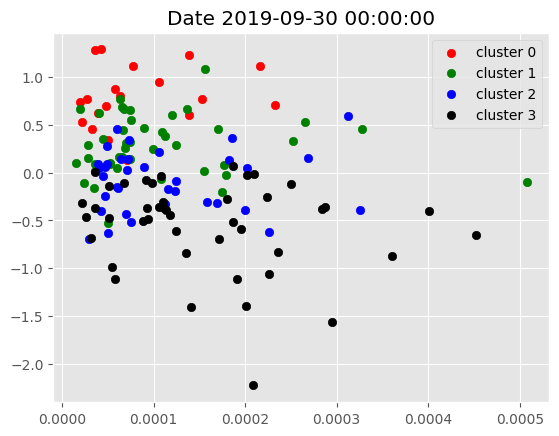

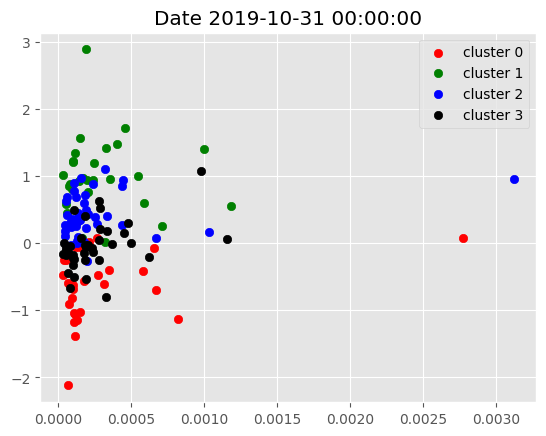

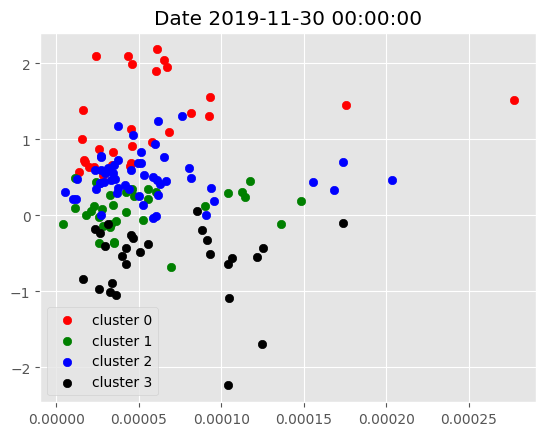

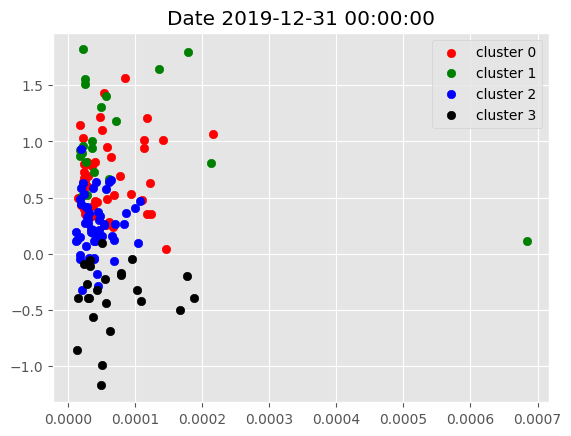

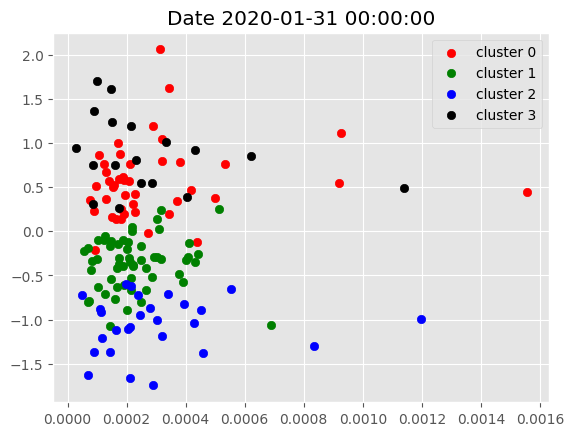

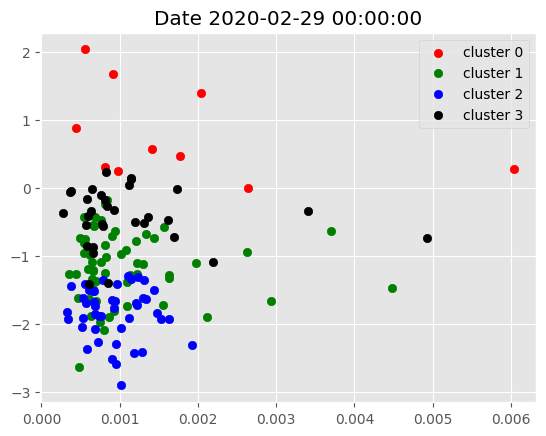

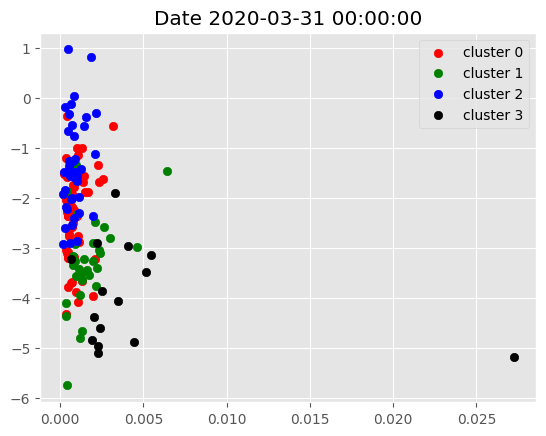

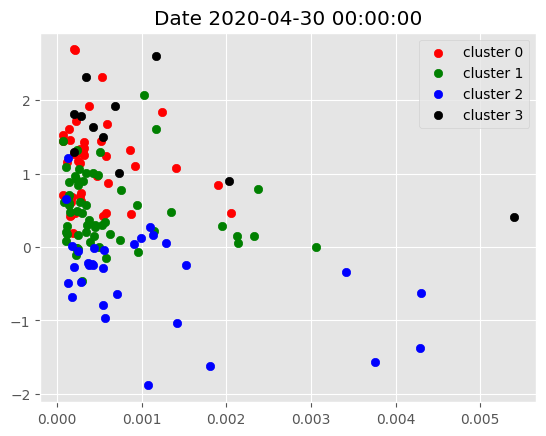

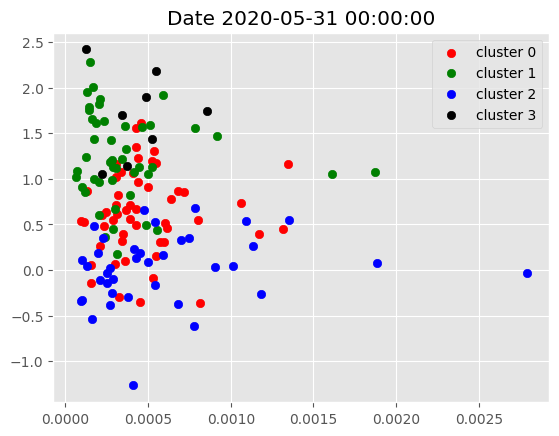

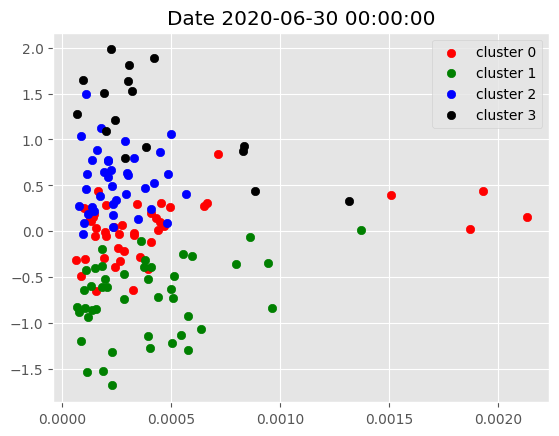

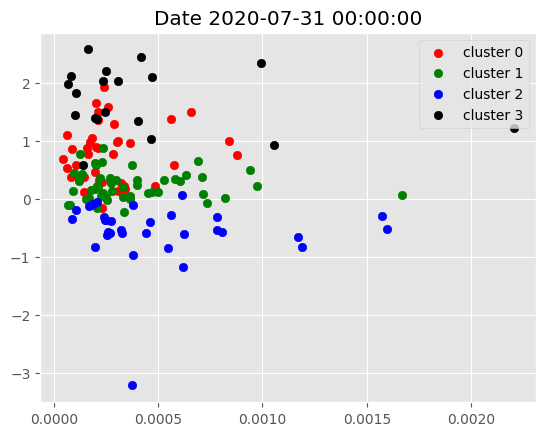

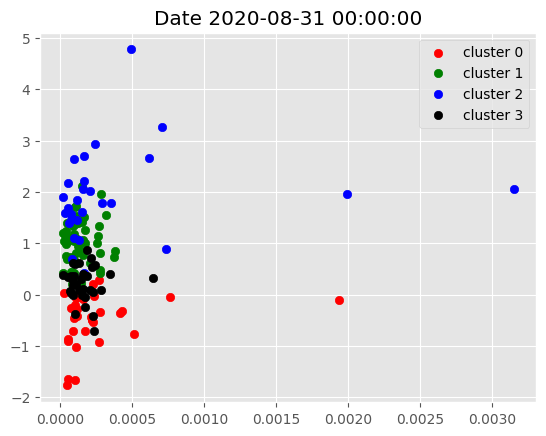

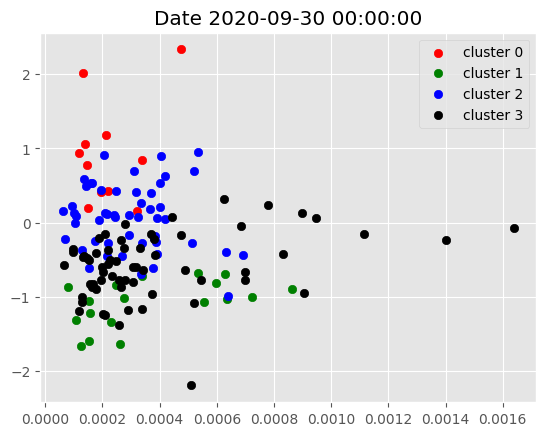

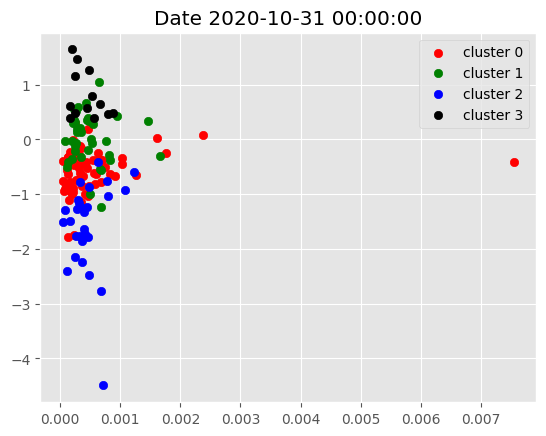

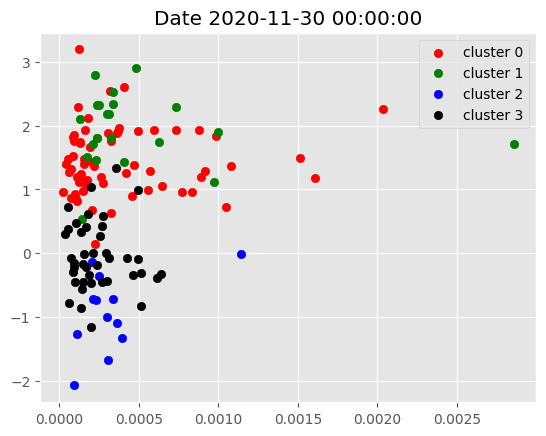

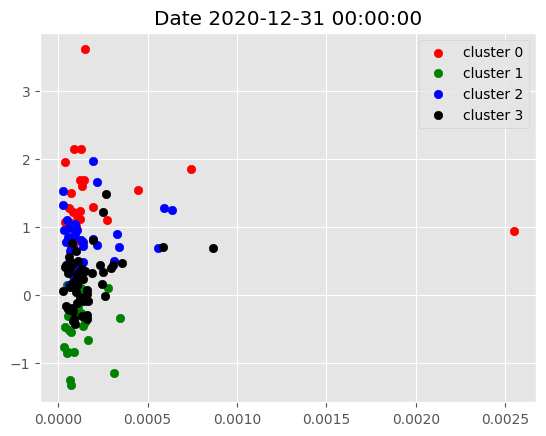

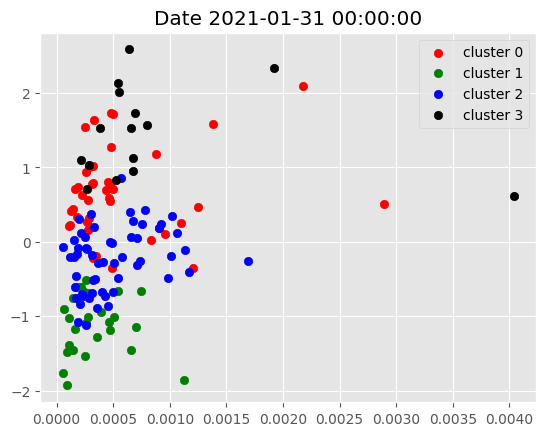

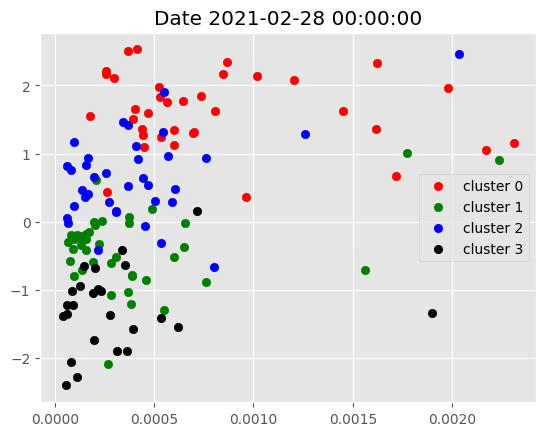

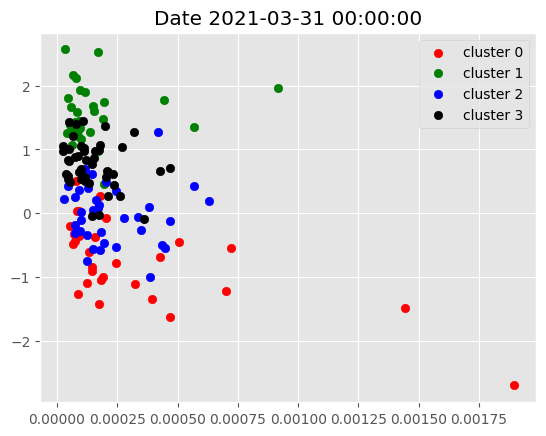

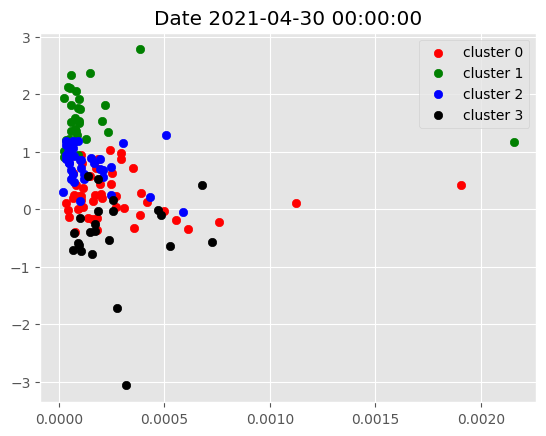

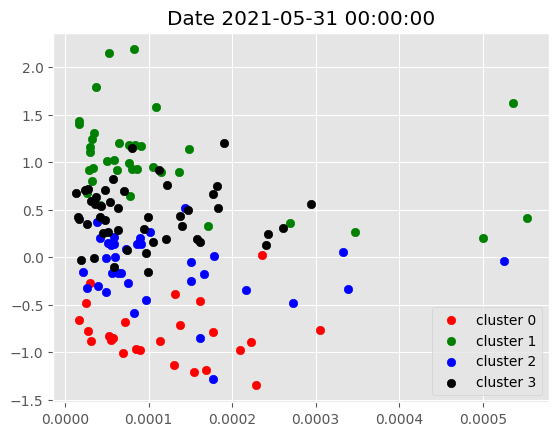

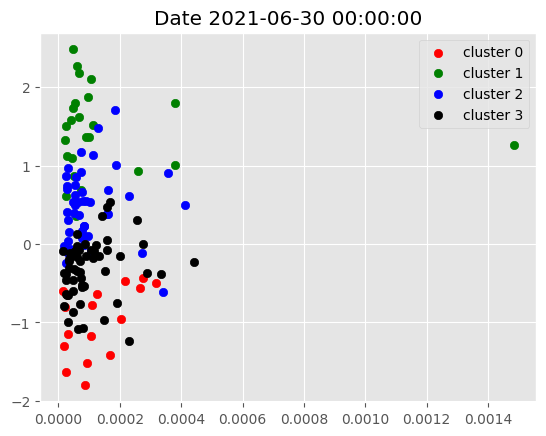

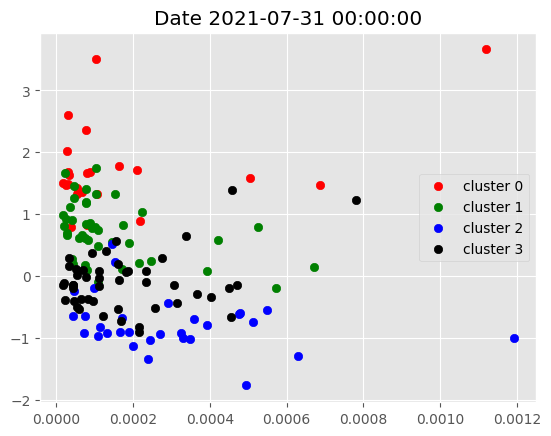

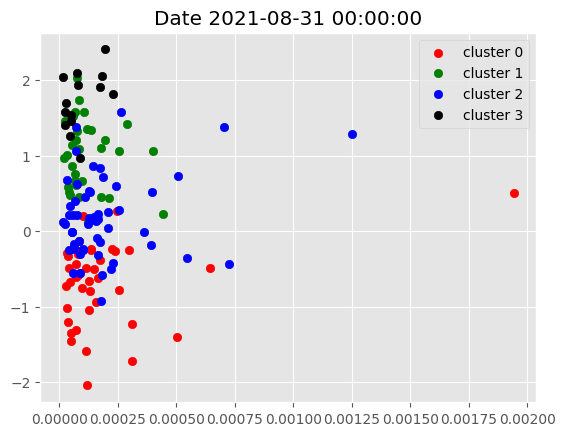

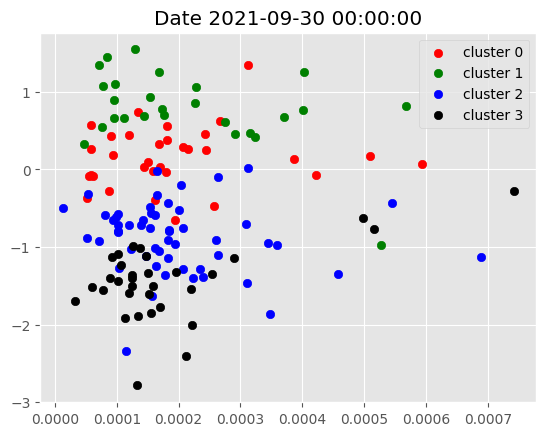

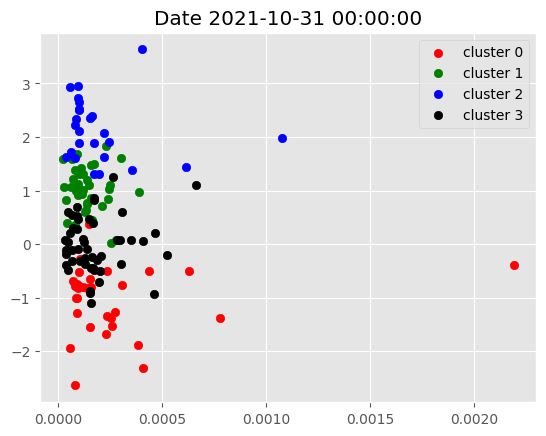

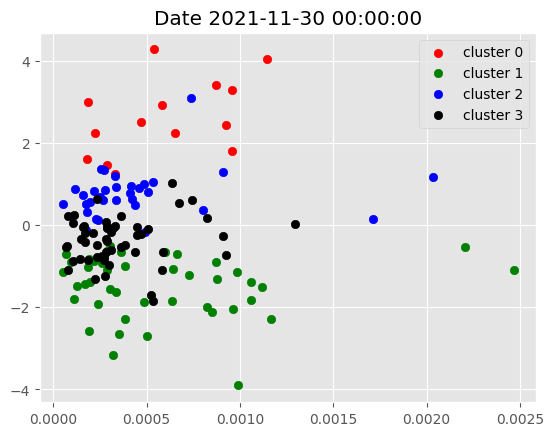

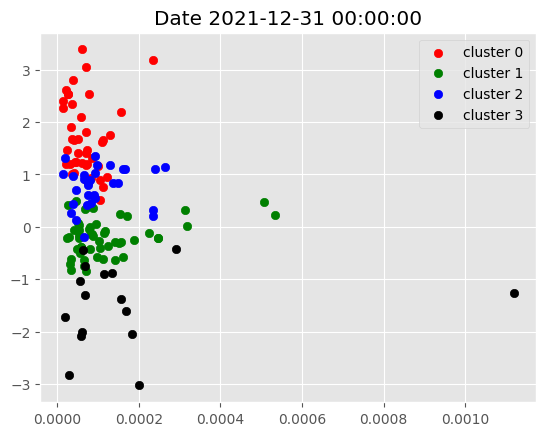

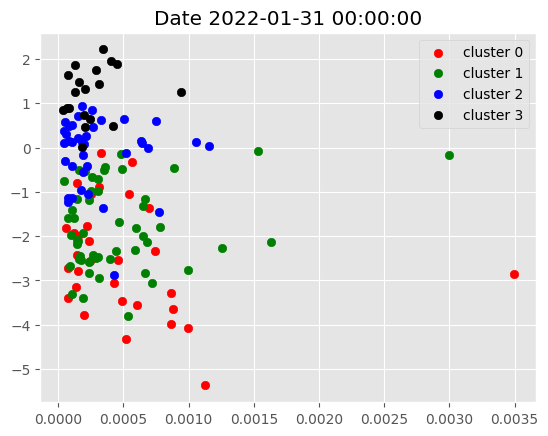

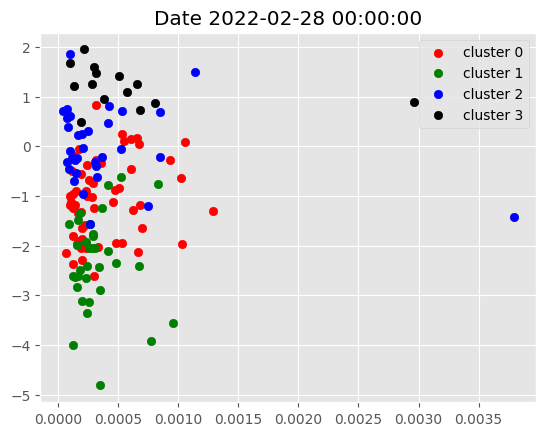

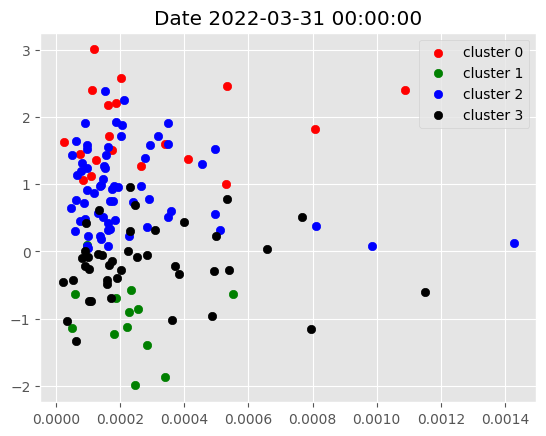

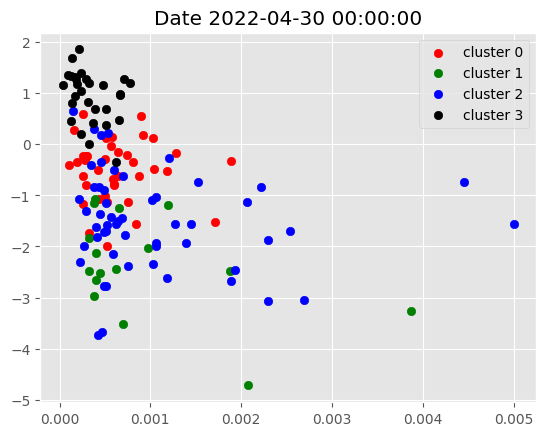

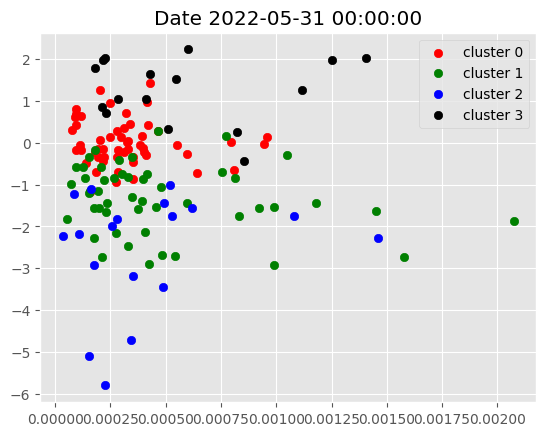

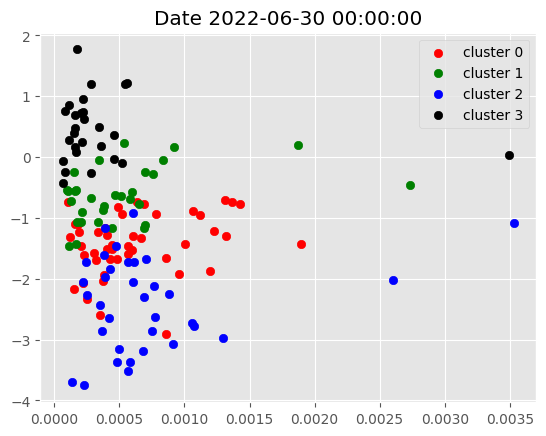

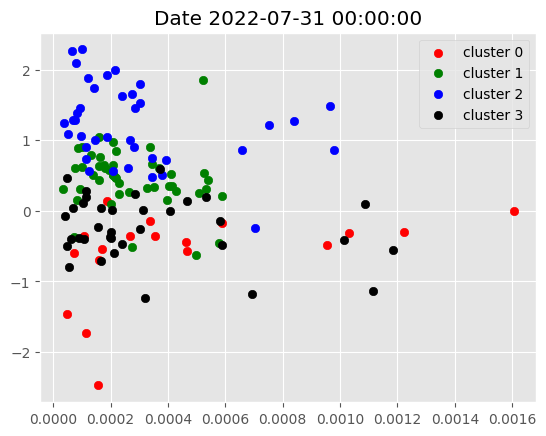

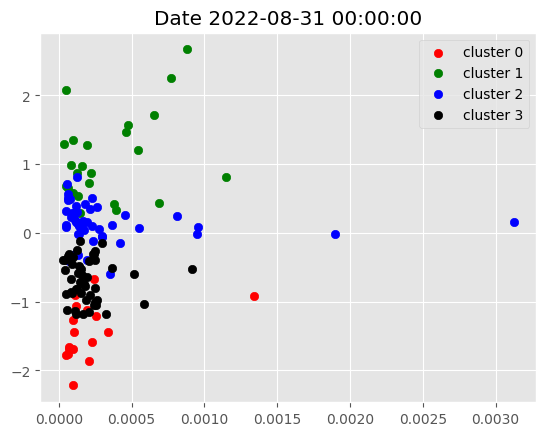

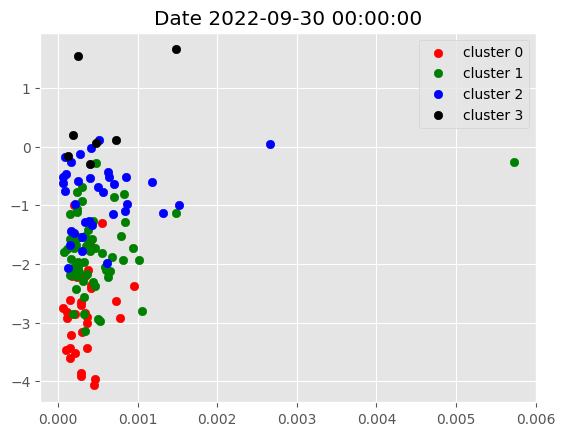

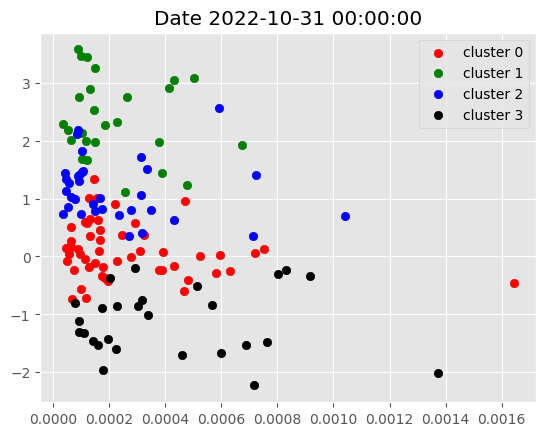

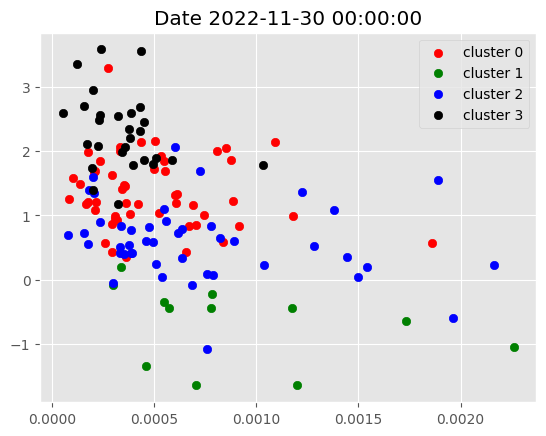

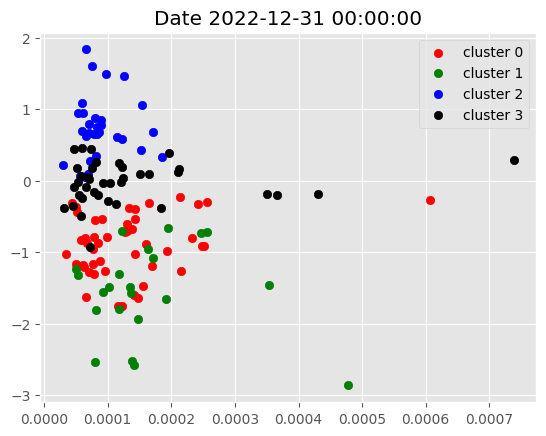

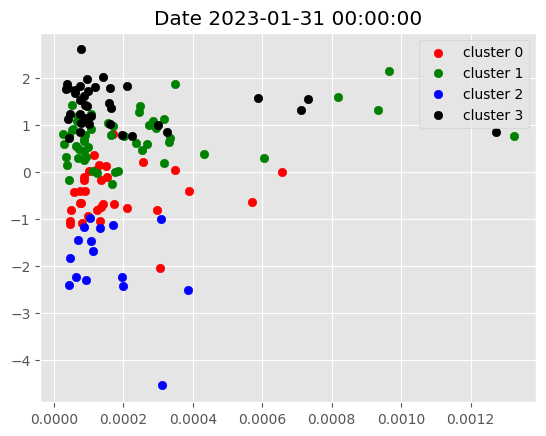

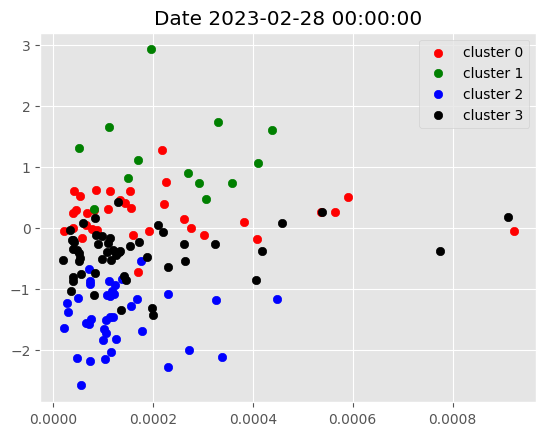

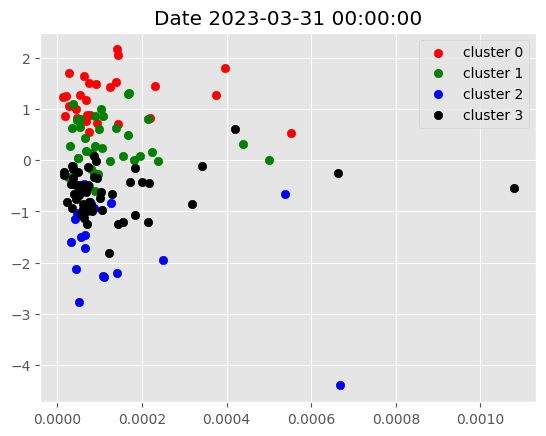

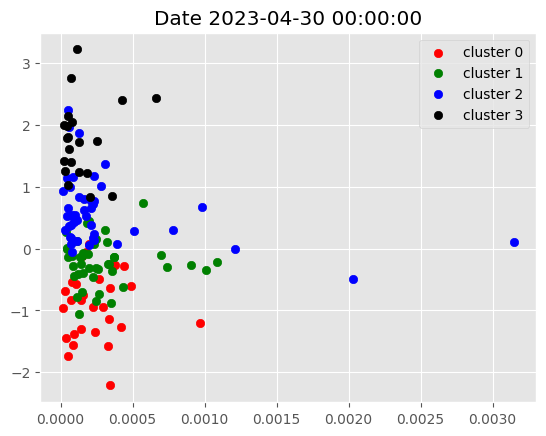

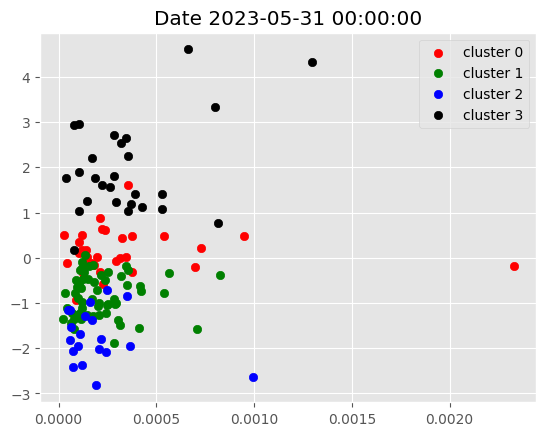

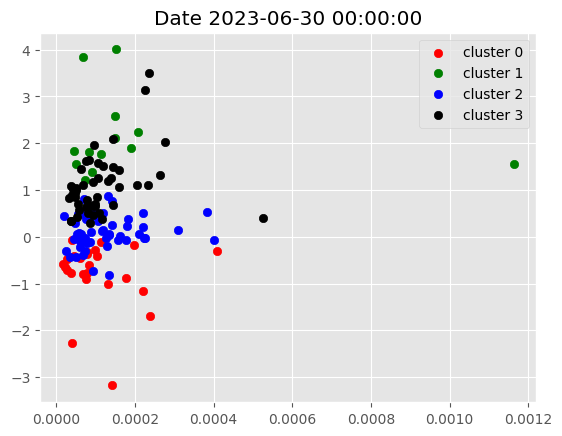

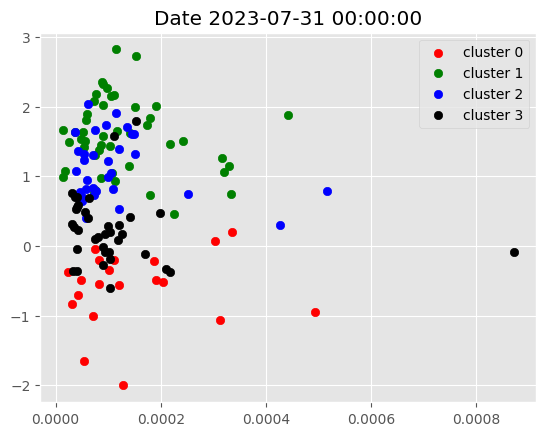

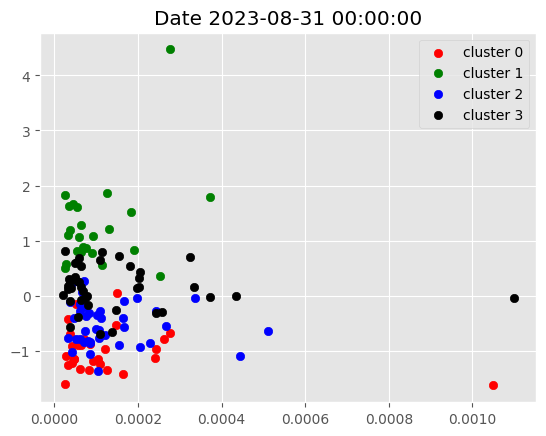

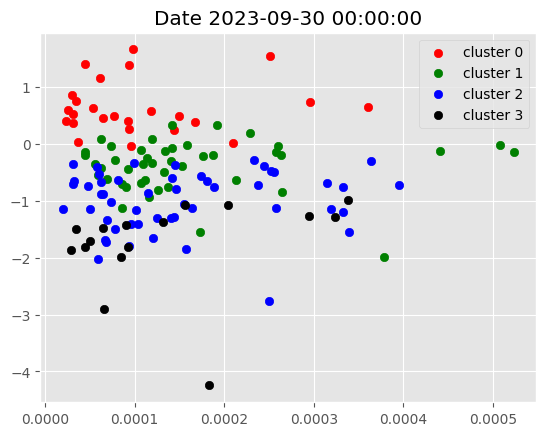

In [ ]:
plt.style.use('ggplot')

for i in data.index.get_level_values('date').unique().tolist():

    g = data.xs(i, level=0)

    plt.title(f'Date {i}')

    plot_clusters(g)

Apply pre-defined centroids.


In [ ]:
target_rsi_values = [30, 45, 55, 70]

initial_centroids = np.zeros((len(target_rsi_values), 18))

initial_centroids[:, 6] = target_rsi_values

initial_centroids

array([[ 0.,  0.,  0.,  0.,  0.,  0., 30.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., 45.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., 55.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., 70.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.]])

## 7. For each month select assets based on the cluster and form a portfolio based on Efficient Frontier max sharpe ratio optimization



* First we will filter only stocks corresponding to the cluster we choose based on our hypothesis.

* Momentum is persistent and my idea would be that stocks clustered around RSI 70 centroid should continue to outperform in the following month - thus I would select stocks corresponding to cluster 3.

In [ ]:
filtered_df = data[data['cluster']==3].copy()

filtered_df = filtered_df.reset_index(level=1)

filtered_df.index = filtered_df.index+pd.DateOffset(1)

filtered_df = filtered_df.reset_index().set_index(['date', 'ticker'])

dates = filtered_df.index.get_level_values('date').unique().tolist()

fixed_dates = {}

for d in dates:

    fixed_dates[d.strftime('%Y-%m-%d')] = filtered_df.xs(d, level=0).index.tolist()

fixed_dates

{'2017-11-01': ['CMG',
  'CVS',
  'EXPE',
  'GE',
  'GILD',
  'MCK',
  'MRK',
  'PG',
  'PM',
  'REGN',
  'T'],
 '2017-12-01': ['AXP',
  'AZO',
  'BA',
  'BLK',
  'COST',
  'CSCO',
  'DE',
  'DLTR',
  'ELV',
  'HD',
  'HON',
  'JPM',
  'KR',
  'MAR',
  'MMM',
  'NKE',
  'SCHW',
  'UNH',
  'UNP',
  'VLO',
  'VZ',
  'WMT'],
 '2018-01-01': ['ABT',
  'ACN',
  'AXP',
  'AZO',
  'BAC',
  'BLK',
  'BRK-B',
  'CL',
  'CMCSA',
  'COP',
  'COST',
  'CSCO',
  'DAL',
  'DG',
  'DLTR',
  'EOG',
  'HON',
  'INTC',
  'JPM',
  'KR',
  'LMT',
  'MO',
  'MPC',
  'MSFT',
  'NKE',
  'NXPI',
  'PEP',
  'PG',
  'SCHW',
  'SHW',
  'SLB',
  'T',
  'TGT',
  'TJX',
  'V',
  'VZ',
  'WFC',
  'WMT',
  'WYNN',
  'XOM'],
 '2018-02-01': ['ABT',
  'AMZN',
  'BA',
  'BAC',
  'BRK-B',
  'CTSH',
  'DG',
  'EA',
  'GD',
  'GOOG',
  'GOOGL',
  'JPM',
  'LMT',
  'LOW',
  'MA',
  'MAR',
  'MSFT',
  'NFLX',
  'NKE',
  'NOC',
  'NVDA',
  'PNC',
  'PYPL',
  'RTX',
  'TMO',
  'V',
  'WFC',
  'WMT'],
 '2018-03-01': ['ABBV',
  'A

###Define portfolio optimization function



* We will define a function which optimizes portfolio weights using PyPortfolioOpt package and EfficientFrontier optimizer to maximize the sharpe ratio.

* To optimize the weights of a given portfolio we would need to supply last 1 year prices to the function.

* Apply signle stock weight bounds constraint for diversification (minimum half of equaly weight and maximum 10% of portfolio).





In [ ]:
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns

def optimize_weights(prices, lower_bound=0):

    returns = expected_returns.mean_historical_return(prices=prices,
                                                      frequency=252)

    cov = risk_models.sample_cov(prices=prices,
                                 frequency=252)

    ef = EfficientFrontier(expected_returns=returns,
                           cov_matrix=cov,
                           weight_bounds=(lower_bound, .1),
                           solver='SCS')

    weights = ef.max_sharpe()

    return ef.clean_weights()

Download Fresh Daily Prices Data only for short listed stocks.

In [ ]:
stocks = data.index.get_level_values('ticker').unique().tolist()

new_df = yf.download(tickers=stocks,
                     start=data.index.get_level_values('date').unique()[0]-pd.DateOffset(months=12),
                     end=data.index.get_level_values('date').unique()[-1])

new_df

[*********************100%***********************]  155 of 155 completed


Price            Close                                                 \
Ticker            AAPL        ABBV        ABT         ACN        ADBE   
Date                                                                    
2016-10-31   26.035643   38.226250  33.321087  101.253761  107.510002   
2016-11-01   25.565556   38.685402  33.159733  101.166656  106.870003   
2016-11-02   25.588495   38.918404  32.862545  103.318199  105.889999   
2016-11-03   25.314217   38.301628  32.590805  101.872215  107.169998   
2016-11-04   25.086031   38.404430  33.193718  102.116135  106.199997   
...                ...         ...        ...         ...         ...   
2023-09-25  174.203156  142.726990  93.269539  306.313019  511.600006   
2023-09-26  170.127090  142.044037  92.082970  300.147919  506.299988   
2023-09-27  168.613358  141.324188  91.413147  303.790924  502.600006   
2023-09-28  168.870621  140.512039  93.891518  290.639343  504.670013   
2023-09-29  169.385071  137.567963  92.676254  296.765808  509.899994   

Price                                                                  ...  \
Ticker             ADP        ADSK        AIG        AMAT         AMD  ...   
Date                                                                   ...   
2016-10-31   71.496872   72.279999  48.865025   26.230553    7.230000  ...   
2016-11-01   71.381912   70.099998  48.057217   26.068192    7.090000  ...   
2016-11-02   73.894890   68.680000  47.954266   25.788570    6.760000  ...   
2016-11-03   73.361084   67.610001  46.053509   25.499931    6.700000  ...   
2016-11-04   73.155800   69.440002  45.443687   25.454828    6.560000  ...   
...                ...         ...        ...         ...         ...  ...   
2023-09-25  228.386383  205.669998  59.234898  133.900742   97.379997  ...   
2023-09-26  225.741165  201.660004  58.405426  131.440140   95.959999  ...   
2023-09-27  230.869919  202.279999  58.167080  132.400848   98.070000  ...   
2023-09-28  231.516953  207.889999  58.424500  135.498642  102.760002  ...   
2023-09-29  228.919281  206.910004  57.776188  135.724091  102.820000  ...   

Price        Volume                                                           \
Ticker          VLO     VRTX        VZ     WDAY      WDC       WFC       WMT   
Date                                                                           
2016-10-31  4969500  1928200  12459400  1147300  4449514  20115900  19167000   
2016-11-01  7816800  2458200  13229400  1091400  5055315  20020200  26515800   
2016-11-02  7317600  2580400  16488200  1127800  5578033  19566600  22935900   
2016-11-03  3855900  2371000  12605100   633300  4223810  14982700  20411700   
2016-11-04  3729900  1902100  14410200   892600  3579509  27391600  21786300   
...             ...      ...       ...      ...      ...       ...       ...   
2023-09-25  3241900   698100  17616900   894200  3553446  10624000  10459500   
2023-09-26  4936800   633600  18841600  1217300  4724565  15219400  14435700   
2023-09-27  3644000   860600  22083500  2338100  3370739  11815500  15711000   
2023-09-28  3587300   578900  18772100  9196300  4342086  12454600  11617200   
2023-09-29  4302200   896800  19787600  4066600  3323376  13124500  18842400   

Price                                    
Ticker         WYNN       XOM       XYZ  
Date                                     
2016-10-31  1341600  16663800   2960600  
2016-11-01  3722300  13050600   8190900  
2016-11-02  2542400  11226100  19503200  
2016-11-03  9050400   8836500   7371500  
2016-11-04  3223800  13877100  13462800  
...             ...       ...       ...  
2023-09-25  1387800  11316000   8841300  
2023-09-26  1454000  11805400  10168200  
2023-09-27  2050000  23976200  11656100  
2023-09-28  1290400  16808100  16585100  
2023-09-29  1326800  18813600  11965300  

[1740 rows x 775 columns]



* Calculate daily returns for each stock which could land up in our portfolio.

* Then loop over each month start, select the stocks for the month and calculate their weights for the next month.

* If the maximum sharpe ratio optimization fails for a given month, apply equally-weighted weights.

* Calculated each day portfolio return.



In [ ]:
returns_dataframe = np.log(new_df.xs('Adj Close', level=0, axis=1)).diff()

portfolio_df = pd.DataFrame()

for start_date in fixed_dates.keys():

    try:

        end_date = (pd.to_datetime(start_date)+pd.offsets.MonthEnd(0)).strftime('%Y-%m-%d')

        cols = fixed_dates[start_date]

        optimization_start_date = (pd.to_datetime(start_date)-pd.DateOffset(months=12)).strftime('%Y-%m-%d')

        optimization_end_date = (pd.to_datetime(start_date)-pd.DateOffset(days=1)).strftime('%Y-%m-%d')

        optimization_df = new_df[optimization_start_date:optimization_end_date].xs('Adj Close', level=0, axis=1)[cols]

        success = False
        try:
            weights = optimize_weights(prices=optimization_df,
                                   lower_bound=round(1/(len(optimization_df.columns)*2),3))

            weights = pd.DataFrame(weights, index=pd.Series(0))

            success = True
        except:
            print(f'Max Sharpe Optimization failed for {start_date}, Continuing with Equal-Weights')

        if success==False:
            weights = pd.DataFrame([1/len(optimization_df.columns) for i in range(len(optimization_df.columns))],
                                     index=optimization_df.columns.tolist(),
                                     columns=pd.Series(0)).T

        temp_df = returns_dataframe[start_date:end_date]

        temp_df = (temp_df.stack().to_frame('return').reset_index(level=0)
                   .merge(weights.stack().to_frame('weight').reset_index(level=0, drop=True),
                          left_index=True,
                          right_index=True)
                   .reset_index().set_index(['Date', 'index']).unstack().stack())

        temp_df.index.names = ['date', 'ticker']

        temp_df['weighted_return'] = temp_df['return']*temp_df['weight']

        temp_df = temp_df.groupby(level=0)['weighted_return'].sum().to_frame('Strategy Return')

        portfolio_df = pd.concat([portfolio_df, temp_df], axis=0)

    except Exception as e:
        print(e)

portfolio_df = portfolio_df.drop_duplicates()

portfolio_df

SyntaxError: invalid syntax (ipython-input-2074972868.py, line 38)